In [117]:
import sys
import os

sys.path.append('/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit')
sys.path.append('/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron')
sys.path.append('/home/paule/open_mc_projects/MC-1D_DT')


from src.neutron_class import Neutron
from src.source_class import Source, _BatchSource, SourceRegion
from src.geometry_classes import Geometry, Material, Region, nuclide_objects
import src.geometry_classes as geom
import src.performance_classes as perf
import src.tally_classes as tally
import src.vectfit as vf
import src.export_simulation_v3 as xpsim
import src.export_print_csv_2 as xpcsv
import src.reconr_v2 as reconr
import src.parallel as parallel

import openmc

openmc.config['cross_sections'] = "/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/cross_sections.xml"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [118]:
# One slab of U238 — simple test case


# ============================================================================
# Uranium atom density
# ============================================================================
# Uranium metal density ~ 19.1 g/cm³,
# N = rho * Na / A  (atoms/cm³)
rho_U   = 19.1               # g/cm³
NA      = 6.02214076e23      # atoms/mol

x_U235 = 0.00                # 0% enrichment
x_U238 = 1.0 - x_U235

M_U8   = 238.05078826        # g/mol
M_U5   = 235.0439299         # g/mol
N_total_U8 = rho_U * NA / (x_U238 * M_U8 + x_U235 * M_U5)
N_total_U5 = rho_U * NA / (x_U235 * M_U5 + x_U238 * M_U8)

N_U235 = 1.0 * N_total_U5   # 0%  enrichment
N_U238 = 1.0 * N_total_U8   # 100%

slab1 = Material(
    name     = "cell 1",
    nuclides = [('U235', N_U238)],
    T        = 293.6,    # K (~20 °C)
)

slab2 = Material(
    name     = "cell 2",
    nuclides = [('U235', N_U238)],
    T        = 2000,     # K
)
print(slab1.endf_thigh)
print(N_U238)



[Material] Processing nuclide pair: U235 (Density: 4.83e+22)
[Material] Processing nuclide pair: U235 (Density: 4.83e+22)
294.0
4.831863374901811e+22


In [119]:
xml_path = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/cross_sections.xml'
lib = openmc.data.DataLibrary.from_xml(xml_path)
_endf_ref_entry = lib.get_by_material('U238', data_type='neutron')
print(min(openmc.data.IncidentNeutron.from_hdf5(_endf_ref_entry['path']).urr['1200K'].energy))
print(geom.temps_endf)
geom.nuclide_objects['U238']['endf'][1]['250K'](50000)
endf = geom.nuclide_objects['U238']['endf']
print(endf[1]['250K'](50000))
print(slab2.endf_tlow)
print(slab2.endf_thigh)

20000.01
[250.0, 294.0, 600.0, 900.0, 1200.0, 2500.0]
13.06079716
1200.0
2500.0


10000


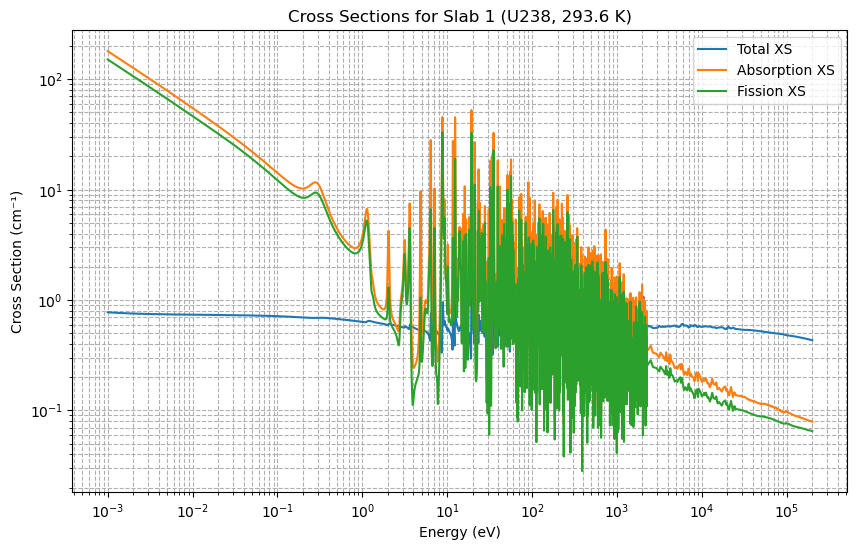

In [120]:
E_test = np.logspace(-3, np.log10(2.0e5), 10000)  # eV
xs_slab1 = np.zeros((len(E_test), 3))  # total, absorption, fission
print(len(E_test))
for i, e in enumerate(E_test):
    
    xs_slab1[i] = slab1._xs_evaluation(e)

# plot the three xs components
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.loglog(E_test, xs_slab1[:, 0], label='Total XS')
plt.loglog(E_test, xs_slab1[:, 1], label='Absorption XS')
plt.loglog(E_test, xs_slab1[:, 2], label='Fission XS')
plt.xlabel('Energy (eV)')
plt.ylabel('Cross Section (cm⁻¹)')
plt.title('Cross Sections for Slab 1 (U238, 293.6 K)')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()


In [121]:
# ============================================================================
# Geometry  (two slabs)
# ============================================================================
model = Geometry(majorant_log=True, poll_interval=0.001, verbose=False)

# ── Materials ────────────────────────────────────────────────────────────────
model.add_material(slab1)
model.add_material(slab2)

# ── Regions (replaces manual boundaries + material_array assignment) ─────────
model.add_region(name="slab1", material=slab1, x_min=0.0,  x_max=2.0)
model.add_region(name="slab2", material=slab2, x_min=2.0,  x_max=15.0)
model.set_boundary_conditions("reflective", "reflective")
last_energy = 1e5

# ── Tallies ──────────────────────────────────────────────────────────────────
energy_bins = [10.0, 50.0, 600.0, 1e4, 1e6, 2e7]  # eV
model.attach_flux_tally(energy_bins)
model.attach_verification_tally(
    energy_bins = energy_bins,
    surface_xs  = [0.0, 2.0, 15.0],
)

# ── Majorant and XS method ───────────────────────────────────────────────────

model.set_maj_xs_method(
    method  = "sqrtT_E",
    T_array = [0, 293, 500, 1000, 1500, 1900, 2000],
    T_bound_method="user_defined",
    T_bounds=(250, 2500)
)
model.set_maj_mat_method(
    err_lim=0.0001,
    err_max=0.001,
    value="simple",
    last_energy=last_energy,   # explicitly set
    keep_reconr_maj_nuclides=True,
)
model.set_access_method("fly", last_energy=last_energy, err_lim=0.0001, err_max=0.001)
model.set_mode("analysis", filename="validation/xs_generation/statepoint.200.h5")

# -- Cutoff energies
model.set_cutoff_energy(1)  # eV

# ============================================================================
# Source
# ============================================================================
N_NEUTRONS = 1000
N_BATCHES  = 20
src = Source.point(
    neutron_nbr    = N_NEUTRONS,
    geometry       = model,
    region_name    = "slab1",
    position       = [0.0, 0.0, 0.0],
    energy_dist    = "flat",
    energy_range   = (1000, 10000),
    direction_dist = "forward",
    direction      = [1.0, 0.0, 0.0],
)



 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Setup] Boundary conditions set: left='reflective', right='reflective'
15.0

 [Memory] Tracker started (poll interval: 1 ms)
Loading table from: /home/paule/open_mc_projects/MC-1D_DT/structured_code/src/sqrtT_E_data
  [Setup] T Bounds for sqrtT_E set: 250 K to 2500 K

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Setup] Cutoff energy set to 1.00e+00 eV


In [122]:
print(model.summary())
print(model.T_min, model.T_max)

  SIMULATION SUMMARY
  Neutrons simulated      :          1
  Absorbed fraction       :     0.000%
  Leaked fraction         :     0.000%
------------------------------------------------------------
  Mean scatters/neutron   :       0.00
  Mean virtual/neutron    :       0.00
  Mean path length  [cm]  :     0.0000
------------------------------------------------------------
  MAJORANT XS DIAGNOSTICS
  Majorant updates        :          0
  Mean majorant [cm⁻¹]    :     0.0000
  Max  majorant [cm⁻¹]    :     0.0000
  Mean margin (maj/real)  :      0.000
  Min margin (maj/real)   :      0.000
  Max margin (maj/real)   :      0.000
  Most-limiting material  : N/A
  Wrong majorant updates  :          0
  Wrong majorant mean error sum : 0.0000
  Wrong majorant rate     : 0.0000
  FLUX TALLY (track-length estimator)
    Energy groups : (5,)
    Histories     : 0
    Bin volumes   : 15.0 cm³
    Mean track length per source neutron [cm · src-n⁻¹]:
[0. 0. 0. 0. 0.]
    Std (of mean) [cm · src-

ValueError: x, y, and format string must not be None

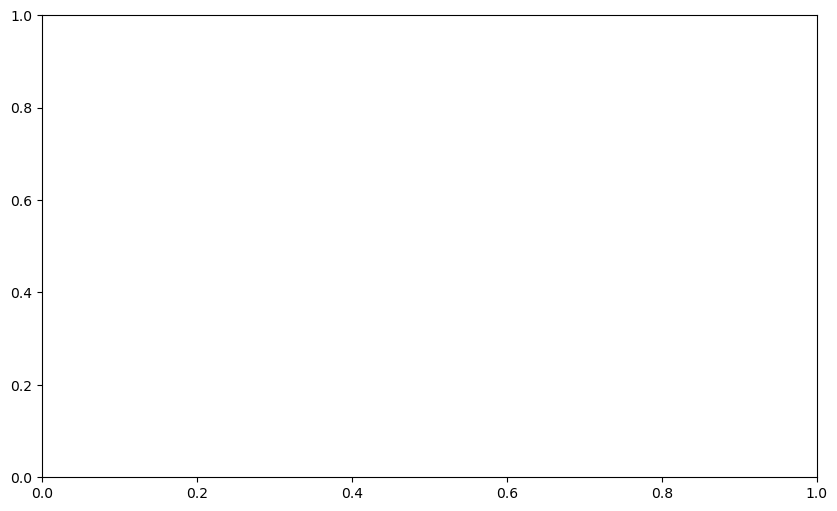

In [123]:
plt.figure(figsize=(10, 6))
plt.plot(model.reconr_e_grid,model.reconr_maj_xs_grid)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (eV)')
plt.ylabel('Cross Section (barns)')
plt.title('Reconstructed Major Nuclide Cross Section')
plt.grid(True, which="both", ls="--")

# save reconr majorant xs data in a CSV file
import pandas as pd
df = pd.DataFrame({
    'Energy (eV)': model.reconr_e_grid,
    'Majorant XS (barns)': model.reconr_maj_xs_grid
})
df.to_csv(f'reconr_majorant_xs_{model.materials[0].name}_{last_energy}_{model.maj_xs_method}_{model.T_min}K_{model.T_max}K_new_sqrt_T_E.csv', index=False)







 [Memory] Tracker started (poll interval: 1 ms)
Loading table from: /home/paule/open_mc_projects/MC-1D_DT/structured_code/src/sqrtT_E_data
  [Setup] T Bounds for sqrtT_E set: 250 K to 2500 K

 [Memory] Tracker stopped.


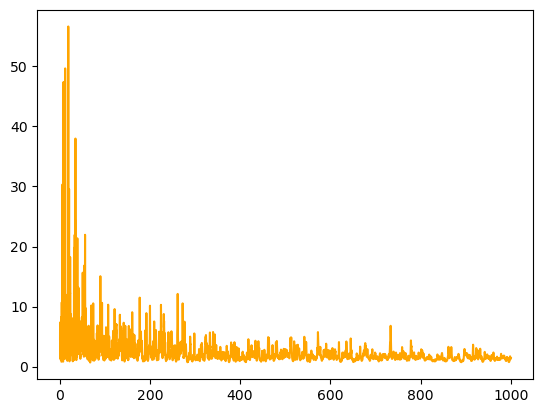

In [124]:
#calculate the majorant without going through reconr, using the same method as in the model but directly on the endf data, and compare to the reconr majorant xs

"""model.set_maj_xs_method(
    method  = "sqrtT_E",
    T_array = [0, 293, 500, 1000, 1500, 1900, 2000],
    T_bound_method="user_defined",
    T_bounds=(250, 2500)
)
model.set_maj_mat_method(
    err_lim=0.0001,
    err_max=0.001,
    value="simple",
    last_energy=last_energy,   # explicitly set
    keep_reconr_maj_nuclides=True,
)
model.set_access_method("fly", last_energy=last_energy, err_lim=0.0001, err_max=0.001)"""

"""model.set_maj_xs_method(
    method  = "sqrtT_E",
    T_array = [0, 293, 500, 1000, 1500, 1900, 2000],
    T_bound_method="user_defined",
    T_bounds=(100, 3000)
)"""

model.set_maj_xs_method(
    method  = "sqrtT_E",
    T_array = [0, 293, 500, 1000, 1500, 1900, 2000],
    T_bound_method="user_defined",
    T_bounds=(250, 2500)
)
n_energies = 100000
energies = np.logspace(np.log10(1), np.log10(1000), n_energies)
xs =[]
for e in energies:
    xs.append(model.calculate_mat_majorant_xs(e))
df = pd.DataFrame({
    'Energy (eV)': energies,
    'Majorant XS (barns)': xs
})
df.to_csv(f'U235_majorant_xs_sampled_{energies[0]}_{energies[-1]}_{model.maj_xs_method}_{model.T_min}K_{model.T_max}K_new_generation_2sides_{n_energies}.csv', index=False)

plt.plot(df['Energy (eV)'], df['Majorant XS (barns)'], label='Calculated Majorant XS', color='orange')

In [125]:
#load both csvs and compare 
df_endf = pd.read_csv('/home/paule/open_mc_projects/MC-1D_DT/structured_code/U235_majorant_xs_sampled_1.0_1000.0_endf_lookup_250K_2500K_new_generation_2sides_100000.csv')
df_sqrT_E = pd.read_csv('/home/paule/open_mc_projects/MC-1D_DT/structured_code/U235_majorant_xs_sampled_1.0_1000.0_sqrtT_E_250K_2500K_new_generation_2sides_100000.csv')
df_vectfit = pd.read_csv('/home/paule/open_mc_projects/MC-1D_DT/structured_code/U238_majorant_xs_sampled_1000.0_10000.0_vectfit_250K_2500K.csv')


#print(model.T_min, model.T_max)
#print(geom.temps_endf)
# check if energy grids are the same
if np.array_equal(df_endf['Energy (eV)'], df_sqrT_E['Energy (eV)']):
    print("Energy grids are the same.")
else:
    print("Energy grids differ.")
    # if they differ, we could interpolate one onto the other's grid for a more direct comparison of the majorant XS values.
    #pick the larger grid and interpolate the smaller one onto it
    if len(df_endf) > len(df_sqrT_E):
        print("Interpolating sqrtT_E onto endf grid...")
        largest_grid_e = df_endf['Energy (eV)']
        smaller_grid_e = df_sqrT_E['Energy (eV)']
        smaller_grid_xs = df_sqrT_E['Majorant XS (barns)']
        interpolated_xs = np.interp(largest_grid_e, smaller_grid_e, smaller_grid_xs)
        df_sqrT_E_interp = pd.DataFrame({
            'Energy (eV)': largest_grid_e,
            'Majorant XS (barns)': interpolated_xs
        })
        df_sqrT_E = df_sqrT_E_interp
        df_vectfit_interp = pd.DataFrame({
            'Energy (eV)': largest_grid_e,
            'Majorant XS (barns)': np.interp(largest_grid_e, df_vectfit['Energy (eV)'], df_vectfit['Majorant XS (barns)'])
        })
        df_vectfit = df_vectfit_interp
    else:
        print("Interpolating endf_lookup onto sqrtT_E grid...")
        largest_grid_e = df_sqrT_E['Energy (eV)']
        smaller_grid_e = df_endf['Energy (eV)']
        smaller_grid_xs = df_endf['Majorant XS (barns)']
        interpolated_xs = np.interp(largest_grid_e, smaller_grid_e, smaller_grid_xs)
        df_endf_interp = pd.DataFrame({
            'Energy (eV)': largest_grid_e,
            'Majorant XS (barns)': interpolated_xs
        })
        df_endf = df_endf_interp

        df_vectfit_interp = pd.DataFrame({
            'Energy (eV)': largest_grid_e,
            'Majorant XS (barns)': np.interp(largest_grid_e, df_vectfit['Energy (eV)'], df_vectfit['Majorant XS (barns)'])
        })
        df_vectfit = df_vectfit_interp



Energy grids are the same.


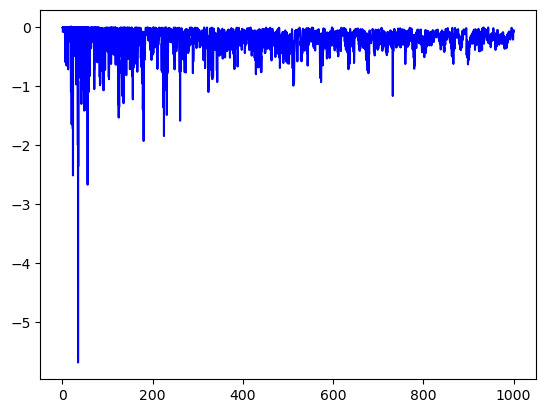

In [126]:
# now we can directly compare the majorant XS values
# calculate the relative difference between the two methods
safety_factor = False
if safety_factor :
    df_sqrT_E['Majorant XS (barns)'] *= 1.01  # apply a 1% safety factor to the sqrtT_E majorant XS values
    df_endf['Majorant XS (barns)'] *= 1.05  # apply a 1% safety factor to the endf_lookup majorant XS values

abs_relative_diff = np.abs(df_endf['Majorant XS (barns)'] - df_sqrT_E['Majorant XS (barns)']) / df_endf['Majorant XS (barns)']
relative_diff = (df_endf['Majorant XS (barns)'] - df_sqrT_E['Majorant XS (barns)']) / df_endf['Majorant XS (barns)']
diff = df_endf['Majorant XS (barns)'] - df_sqrT_E['Majorant XS (barns)']
mask = relative_diff >= 1.e-6

plt.plot(df_endf['Energy (eV)'], diff, color='blue', label='Relative Difference')

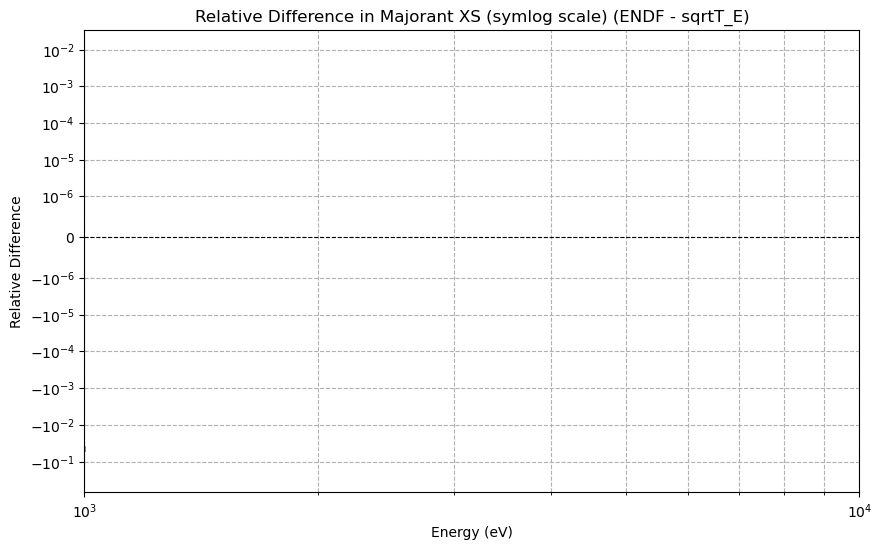

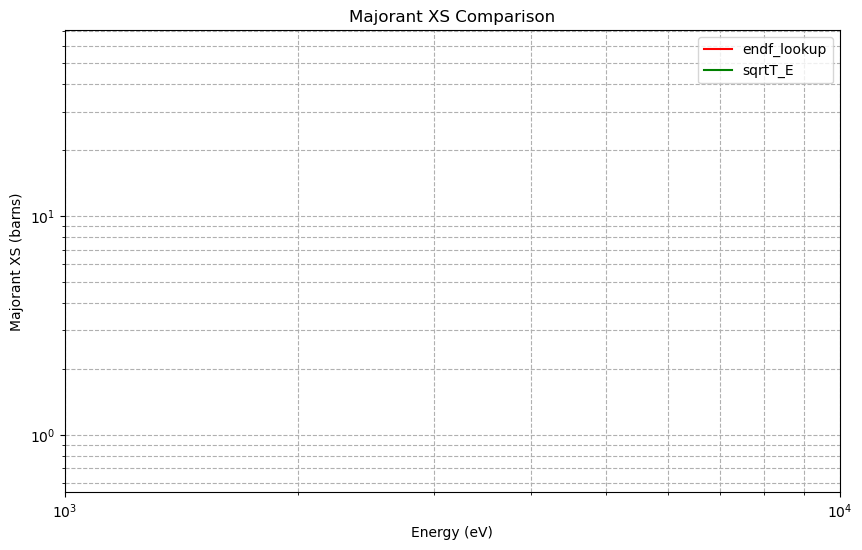

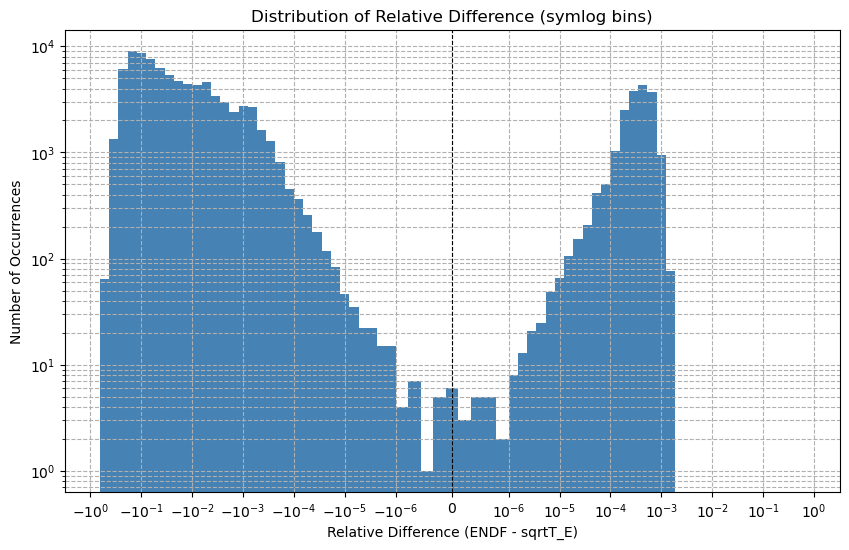

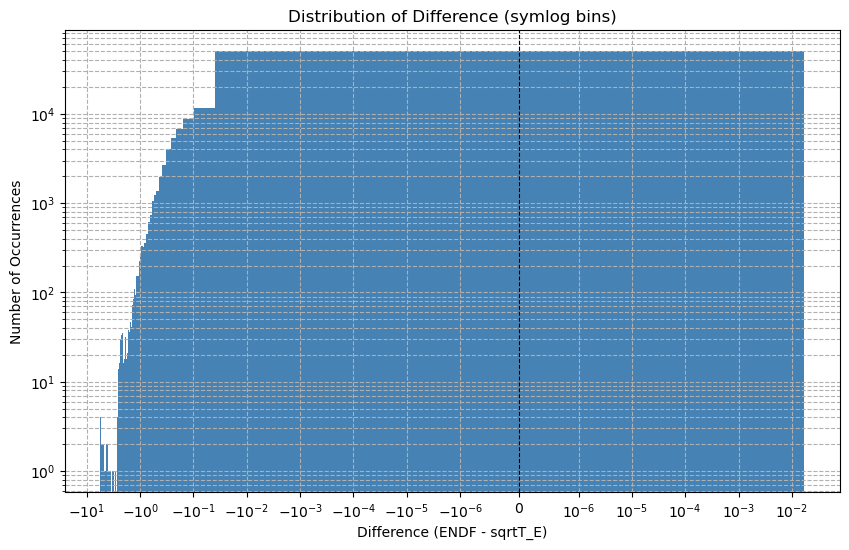

In [127]:


plt.figure(figsize=(10, 6))
plt.plot(df_endf['Energy (eV)'], relative_diff, color='blue', label='Relative Difference')
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-6)  # linear between -1e-6 and 1e-6, log outside
plt.xlim(1000, 10000)
plt.xlabel('Energy (eV)')
plt.ylabel('Relative Difference')
plt.title('Relative Difference in Majorant XS (symlog scale) (ENDF - sqrtT_E)')
plt.grid(True, which="both", ls="--")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # zero reference line

#plot both majorant XS curves on the same plot for visual comparison
plt.figure(figsize=(10, 6))
plt.plot(df_endf['Energy (eV)'], df_endf['Majorant XS (barns)'], label='endf_lookup', color='red')
plt.plot(df_sqrT_E['Energy (eV)'], df_sqrT_E['Majorant XS (barns)'], label='sqrtT_E', color='green')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1000, 10000)
plt.xlabel('Energy (eV)')
plt.ylabel('Majorant XS (barns)')
plt.title('Majorant XS Comparison')
plt.legend()
plt.grid(True, which="both", ls="--")

import matplotlib.ticker as ticker
# Define symlog bin edges
linthresh = 1e-6
n_bins = 100

# Log-spaced bins for positive and negative sides + linear region around 0
neg_bins = -np.logspace(np.log10(relative_diff.abs().max()), np.log10(linthresh), n_bins // 3)
lin_bins = np.linspace(-linthresh, linthresh, 10)
pos_bins = np.logspace(np.log10(linthresh), np.log10(relative_diff.abs().max()), n_bins // 3)

bin_edges = np.concatenate([neg_bins, lin_bins, pos_bins])
bin_edges = np.sort(np.unique(bin_edges))  # remove duplicates and sort

plt.figure(figsize=(10, 6))
plt.hist(relative_diff.dropna(), bins=bin_edges, color='steelblue', edgecolor='none')
plt.xscale('symlog', linthresh=linthresh)
plt.yscale('log')
plt.xlabel('Relative Difference (ENDF - sqrtT_E)')
plt.ylabel('Number of Occurrences')
plt.title('Distribution of Relative Difference (symlog bins)')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, which="both", ls="--")

plt.figure(figsize=(10, 6))
plt.hist(diff.dropna(), bins=100, color='steelblue', edgecolor='none')
plt.xscale('symlog', linthresh=linthresh)
plt.yscale('log')
plt.xlabel('Difference (ENDF - sqrtT_E)')
plt.ylabel('Number of Occurrences')
plt.title('Distribution of Difference (symlog bins)')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, which="both", ls="--")


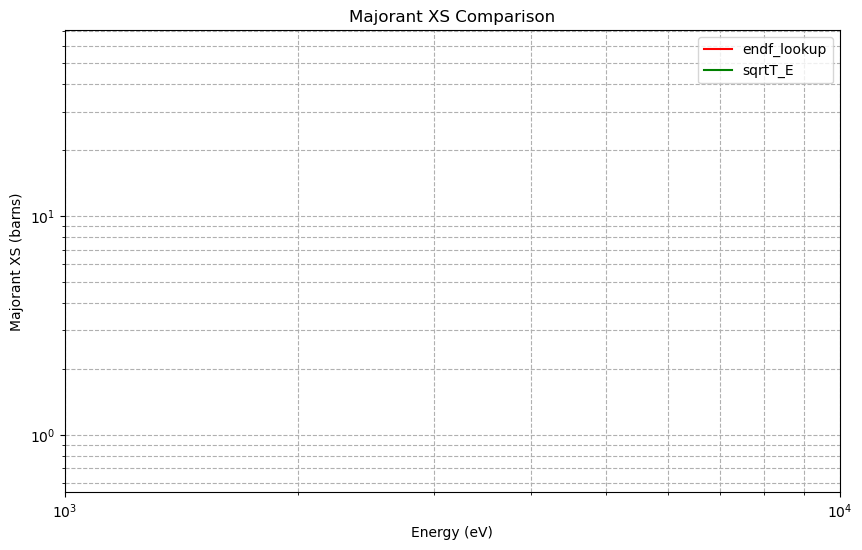

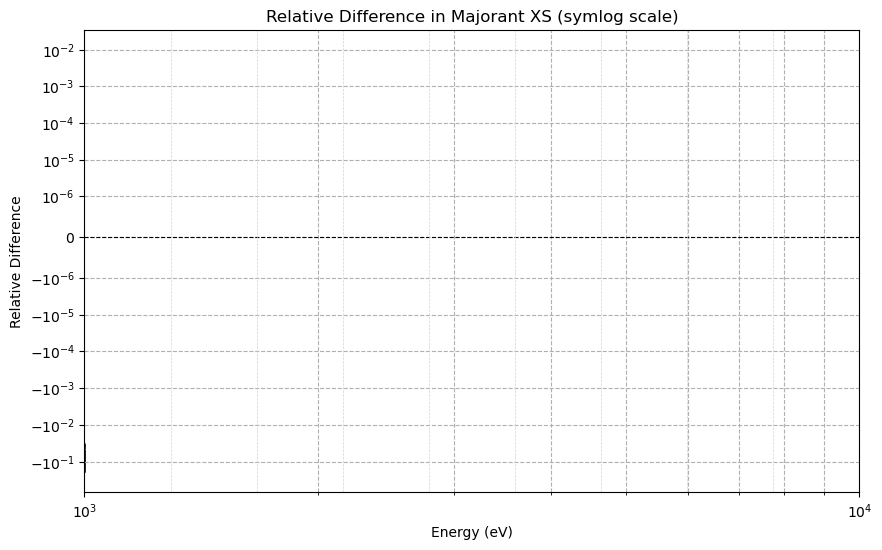

In [128]:
x_lim = (1000, 10000)


#plot both majorant XS curves on the same plot for visual comparison
plt.figure(figsize=(10, 6))
plt.plot(df_endf['Energy (eV)'], df_endf['Majorant XS (barns)'], label='endf_lookup', color='red')
plt.plot(df_sqrT_E['Energy (eV)'], df_sqrT_E['Majorant XS (barns)'], label='sqrtT_E', color='green')
plt.xlim(*x_lim)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (eV)')
plt.ylabel('Majorant XS (barns)')
plt.title('Majorant XS Comparison')
plt.legend()
plt.grid(True, which="both", ls="--")

plt.figure(figsize=(10, 6))
plt.scatter(df_endf['Energy (eV)'], relative_diff, color='blue', label='Relative Difference', s=1)
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-6)  # linear between -1e-6 and 1e-6, log outside
plt.xlim(*x_lim)
plt.xlabel('Energy (eV)')
plt.ylabel('Relative Difference')
plt.title('Relative Difference in Majorant XS (symlog scale)')
plt.grid(True, which="both", ls="--")
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # zero reference line
# add a  denser vertical grid 
for energy in np.logspace(np.log10(x_lim[0]), np.log10(x_lim[1]), 10):
    plt.axvline(energy, color='lightgrey', linewidth=0.5, linestyle='--')







In [129]:
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

linthresh = 1e-6

# ── U238 WMP window boundaries (computed once at module level) ────────────────
u238_wmp        = nuclide_objects['U238']['wmp']
n_windows       = u238_wmp.windows.shape[0]
sqrt_E_min      = np.sqrt(u238_wmp.E_min)
spacing         = u238_wmp.spacing
sqrt_boundaries = sqrt_E_min + np.arange(n_windows + 1) * spacing
all_window_E    = sqrt_boundaries ** 2

# keep only boundaries inside the plot energy range
E_plot_min = df_endf['Energy (eV)'].min()
E_plot_max = df_endf['Energy (eV)'].max()
window_energies = all_window_E[
    (all_window_E >= E_plot_min) & (all_window_E <= E_plot_max)
]

# ─────────────────────────────────────────────────────────────────────────────

def symlog_transform(x, linthresh=1e-6):
    return np.sign(x) * np.where(
        np.abs(x) < linthresh,
        np.abs(x) / linthresh,
        1 + np.log10(np.abs(x) / linthresh)
    )

def get_symlog_ticks(data_slice, linthresh=1e-6):
    if len(data_slice) == 0 or data_slice.isna().all():
        return [], []

    vmin, vmax = data_slice.min(), data_slice.max()

    if vmax > linthresh:
        pos_exp_max  = int(np.floor(np.log10(vmax)))
        pos_exponents = np.arange(-6, pos_exp_max + 1)
        pos_ticks_raw = 10.0 ** pos_exponents
        pos_labels    = [f"1e{e}" for e in pos_exponents]
    else:
        pos_ticks_raw, pos_labels = np.array([]), []

    if vmin < -linthresh:
        neg_exp_max  = int(np.floor(np.log10(np.abs(vmin))))
        neg_exponents = np.arange(-6, neg_exp_max + 1)
        neg_ticks_raw = -10.0 ** neg_exponents
        neg_labels    = [f"-1e{e}" for e in neg_exponents]
    else:
        neg_ticks_raw, neg_labels = np.array([]), []

    tick_vals_raw = np.concatenate([neg_ticks_raw[::-1], [0], pos_ticks_raw])
    tick_vals_transformed = symlog_transform(tick_vals_raw, linthresh)
    tick_labels = neg_labels[::-1] + ["0"] + pos_labels

    return tick_vals_transformed.tolist(), tick_labels


def build_figure(x_range=None):
    if x_range is not None:
        xmin, xmax = 10**x_range[0], 10**x_range[1]
        mask = (df_endf['Energy (eV)'] >= xmin) & (df_endf['Energy (eV)'] <= xmax)
        # filter window boundaries to the visible range
        visible_windows = window_energies[
            (window_energies >= xmin) & (window_energies <= xmax)
        ]
    else:
        mask            = slice(None)
        visible_windows = window_energies   # already clipped to plot range

    endf_slice  = df_endf[mask]
    sqrte_slice = df_sqrT_E[mask]
    vectfit_slice = df_vectfit[mask]
    rd_slice    = relative_diff[mask]

    tickvals, ticklabels = get_symlog_ticks(rd_slice, linthresh)

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        subplot_titles=('Majorant XS Comparison', 'Relative Difference (symlog scale)')
    )

    # ── traces ────────────────────────────────────────────────────────────────
    fig.add_trace(go.Scattergl(
        x=endf_slice['Energy (eV)'],
        y=endf_slice['Majorant XS (barns)'],
        name='endf_lookup', line=dict(color='red', width=1)
    ), row=1, col=1)

    fig.add_trace(go.Scattergl(
        x=sqrte_slice['Energy (eV)'],
        y=sqrte_slice['Majorant XS (barns)'],
        name='sqrtT_E', line=dict(color='green', width=1)
    ), row=1, col=1)

    """fig.add_trace(go.Scattergl(
        x=vectfit_slice['Energy (eV)'],
        y=vectfit_slice['Majorant XS (barns)'],
        name='vectfit', line=dict(color='blue', width=1)
    ), row=1, col=1)"""

    fig.add_trace(go.Scattergl(
        x=endf_slice['Energy (eV)'],
        y=symlog_transform(rd_slice.values, linthresh),
        name='Relative Difference',
        mode='markers', marker=dict(color='blue', size=2)
    ), row=2, col=1)

    fig.add_hline(y=0, line=dict(color='black', width=0.8, dash='dash'), row=2, col=1)

# ── U238 window boundaries — single trace per row ─────────────────────────
# ── U238 window boundaries — one trace per row ────────────────────────────
    wx, wy = [], []
    for E in visible_windows:
        wx += [E, E, None]
        wy += [-1, 1, None]

    for row in [1, 2]:
        fig.add_trace(go.Scattergl(
            x=wx, y=wy,
            mode='lines',
            line=dict(color='blue', width=0.4),
            opacity=0.3,
            showlegend=False,
            hoverinfo='skip',
        ), row=row, col=1)
    # ── layout ────────────────────────────────────────────────────────────────
    fig.update_layout(height=700, hovermode='x unified')
    fig.update_xaxes(type='log', showgrid=True, gridcolor='lightgrey',
                     minor=dict(showgrid=True, gridcolor='lightgrey'))
    fig.update_yaxes(type='log', showgrid=True, gridcolor='lightgrey',
                     minor=dict(showgrid=True, gridcolor='lightgrey'), row=1, col=1)
    fig.update_yaxes(tickvals=tickvals, ticktext=ticklabels,
                     showgrid=True, gridcolor='lightgrey', row=2, col=1)
    fig.update_xaxes(title_text='Energy (eV)', row=2, col=1)
    fig.update_yaxes(title_text='Majorant XS (barns)', row=1, col=1)
    fig.update_yaxes(title_text='Relative Difference',  row=2, col=1)

    if x_range is not None:
        fig.update_xaxes(range=x_range)

    return fig


# --- Dash app ---
app = Dash(__name__)
app.layout = html.Div([
    dcc.Graph(id='main-plot', figure=build_figure(), style={'height': '700px'})
])

@app.callback(
    Output('main-plot', 'figure'),
    Input('main-plot', 'relayoutData'),
    prevent_initial_call=True
)
def on_zoom(relayout):
    if relayout is None:
        return no_update

    if 'xaxis.range[0]' in relayout:
        x_range = [relayout['xaxis.range[0]'], relayout['xaxis.range[1]']]
        return build_figure(x_range=x_range)

    if 'xaxis.autorange' in relayout:
        return build_figure()

    return no_update

app.run(jupyter_mode='inline', port=8052)

/tmp/ipykernel_972921/985404243.py:29: RuntimeWarning:

divide by zero encountered in log10



In [ ]:
model.calculate_reconr_majorant_materials(last_energy=last_energy)

NameError: name 'model' is not defined

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# full geometry majorant
plt.loglog(model.reconr_e_grid, model.reconr_maj_xs_grid, 
           label='Geometry majorant', linewidth=2)

# per-nuclide majorants
for nuclide_name, grid in model.reconr_maj_materials.items():
    print(grid)
    plt.loglog(grid['e_grid'], grid['maj_xs_grid'], 
               label=f"{nuclide_name} majorant", linestyle='--')

plt.xlabel('Energy (eV)')
plt.ylabel('Cross Section (cm⁻¹)')
plt.title('Majorant XS from RECONR')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.show()

print(slab1.nuclides)
print(slab2.nuclides)

NameError: name 'model' is not defined

<Figure size 1000x600 with 0 Axes>

In [14]:
model.draw()

NameError: name 'model' is not defined

In [15]:
from time import perf_counter, sleep
endf_am241 = geom.nuclide_objects['U238']['endf']

# make timer 
t_start = perf_counter()
total = endf_am241[1]['294K'](5000)
t_total = perf_counter() - t_start

t_start = perf_counter()
absorption = endf_am241[27]['294K'](5000)
t_absorption = perf_counter() - t_start
t_start = perf_counter()
fission = endf_am241[18]['294K'](5000)
t_fission = perf_counter() - t_start

t_start = perf_counter()

scattering = total - absorption 
t_scattering = perf_counter() - t_start

print(f"Total XS at 1000 eV and 294 K: {total:.6e} cm⁻¹ in {t_total:.6f} seconds")
print(f"Scattering XS at 1000 eV and 294 K: {scattering:.6e} cm⁻¹ in {t_scattering:.6f} seconds")
print(f"Absorption XS at 1000 eV and 294 K: {absorption:.6e} cm⁻¹ in {t_absorption:.6f} seconds")
print(f"Fission XS at 1000 eV and 294 K: {fission:.6e} cm⁻¹ in {t_fission:.6f} seconds")

print("Total = Scattering + Absorption")
print(f"Total - Absorption: {total - absorption:.6e} cm⁻¹")
print(f"Scattering: {scattering:.6e} cm⁻¹")
print(f"difference: {total - absorption - scattering:.6e} cm⁻¹")
len(endf_am241[1]['294K'].x)



NameError: name 'geom' is not defined

In [16]:
print(model.summary())

NameError: name 'model' is not defined

In [134]:
N_NEUTRONS = 1000
N_BATCHES  = 20
model.set_maj_xs_method("endf_lookup", T_bound_method="user_defined", T_bounds=(250, 2500))

src = Source.point(
    neutron_nbr    = N_NEUTRONS,
    geometry       = model,
    region_name    = "slab1",
    position       = [0.0, 0.0, 0.0],
    energy_dist    = "flat",
    energy_range   = (1, 1000),
    direction_dist = "forward",
    direction      = [1.0, 0.0, 0.0],
)
print(src.neutron_nbr)
model.perf.reset_counters()
print(f"mode: {model.mode}")
print(f"majorant XS method: {model.maj_xs_method}")
print(f"majorant material method: {model.maj_mat_method}")
print(f"access method: {model.access_method}")
batch_stats = model.run_batch(src, n_batches=N_BATCHES, n_workers=20, mode="parallel")



#xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= False, save_csv= True, output_dir=f'cross_batch_stats_{geom.maj_xs_method}_{geom.maj_mat_method}_reconr_v2_new.csv')




 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
1000
mode: analysis
majorant XS method: endf_lookup
majorant material method: simple
access method: fly

 [Memory] Tracker started (poll interval: 1 ms)

[Parallel] Running 20 batches on 20 workers...

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)
[Simulation] Running source (Mode: analysis)


[Simulation] Running source (Mode: analysis)
[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)


[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)
[Simulation] Running source (Mode: analysis)


[Simulation] Running source (Mode: analysis)
[Simulation] Running source (Mode: analysis)


[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mo


  GEOMETRY CONFIGURATION

  Mode                           analysis
  Majorant XS method             endf_lookup
  Access method                  fly
  Cutoff energy [eV]             1.000e+00
  Boundary conditions            left=reflective  right=reflective

  Flux tally                     ON
  Verification tally             ON
  Performance tracker            ON
  Majorant log                   ON
  Neutron history                OFF
  Memory tracker                 ON

  REGIONS  (2 total)
  Name                 Material              x_min      x_max      Width
  --------------------------------------------------------------------
  slab1                cell 1               0.0000     2.0000     2.0000  cm
  slab2                cell 2               2.0000    15.0000    13.0000  cm
  Total geometry width                                           15.0000  cm

  MATERIALS  (2 unique)
  --------------------------------------------------------------------
  cell 1  (T = 293.6 K,  tot

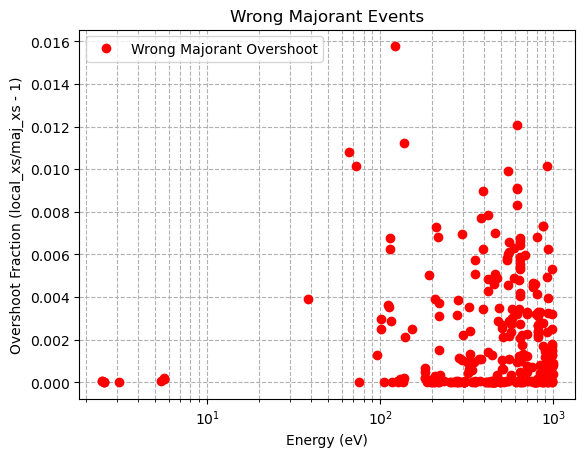

In [136]:
import src.export_print_csv_2 as xpcsv
import pandas as pd
import matplotlib.pyplot as plt

xpcsv.export_cross_batch_stats(batch_stats, source=src, geom=model, print_to_console=True, save_csv=True)

df_wrong_maj = pd.DataFrame(
    model.all_wrong_majorant_energies,
    columns=['Energy (eV)', 'Overshoot Fraction']
)
print(f"Wrong majorant events: {len(df_wrong_maj)}")

plt.plot(df_wrong_maj['Energy (eV)'], df_wrong_maj['Overshoot Fraction'], 'ro', label='Wrong Majorant Overshoot')
plt.xscale('log')
plt.grid(True, which='both', ls='--')
plt.xlabel('Energy (eV)')
plt.ylabel('Overshoot Fraction (local_xs/maj_xs - 1)')
plt.title('Wrong Majorant Events')
plt.legend()
plt.show()

In [137]:
# just before build_figure(), extract U238 window boundaries
u238_wmp = nuclide_objects['U238']['wmp']
u238_windows = u238_wmp.windows  # shape (n_windows, 2) — each row is [E_low, E_high]
u238_window_energies = np.unique(u238_windows.flatten())  # all unique boundary energies

In [138]:
from dash import Dash, dcc, html, Input, Output, no_update
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

linthresh = 1e-6

# ── U238 WMP window boundaries (computed once at module level) ────────────────
u238_wmp        = nuclide_objects['U238']['wmp']
n_windows       = u238_wmp.windows.shape[0]
sqrt_E_min      = np.sqrt(u238_wmp.E_min)
spacing         = u238_wmp.spacing
sqrt_boundaries = sqrt_E_min + np.arange(n_windows + 1) * spacing
all_window_E    = sqrt_boundaries ** 2

E_plot_min      = df_endf['Energy (eV)'].min()
E_plot_max      = df_endf['Energy (eV)'].max()
window_energies= []
"""window_energies = all_window_E[
    (all_window_E >= E_plot_min) & (all_window_E <= E_plot_max)
]"""

# ─────────────────────────────────────────────────────────────────────────────

def symlog_transform(x, linthresh=1e-6):
    return np.sign(x) * np.where(
        np.abs(x) < linthresh,
        np.abs(x) / linthresh,
        1 + np.log10(np.abs(x) / linthresh)
    )

def get_symlog_ticks(data_slice, linthresh=1e-6):
    if len(data_slice) == 0 or data_slice.isna().all():
        return [], []

    vmin, vmax = data_slice.min(), data_slice.max()

    if vmax > linthresh:
        pos_exp_max   = int(np.floor(np.log10(vmax)))
        pos_exponents = np.arange(-6, pos_exp_max + 1)
        pos_ticks_raw = 10.0 ** pos_exponents
        pos_labels    = [f"1e{e}" for e in pos_exponents]
    else:
        pos_ticks_raw, pos_labels = np.array([]), []

    if vmin < -linthresh:
        neg_exp_max   = int(np.floor(np.log10(np.abs(vmin))))
        neg_exponents = np.arange(-6, neg_exp_max + 1)
        neg_ticks_raw = -10.0 ** neg_exponents
        neg_labels    = [f"-1e{e}" for e in neg_exponents]
    else:
        neg_ticks_raw, neg_labels = np.array([]), []

    tick_vals_raw         = np.concatenate([neg_ticks_raw[::-1], [0], pos_ticks_raw])
    tick_vals_transformed = symlog_transform(tick_vals_raw, linthresh)
    tick_labels           = neg_labels[::-1] + ["0"] + pos_labels

    return tick_vals_transformed.tolist(), tick_labels


def build_figure(x_range=None):
    if x_range is not None:
        xmin, xmax = 10**x_range[0], 10**x_range[1]
        mask    = (df_endf['Energy (eV)'] >= xmin) & (df_endf['Energy (eV)'] <= xmax)
        wm_mask = (df_wrong_maj['Energy (eV)'] >= xmin) & (df_wrong_maj['Energy (eV)'] <= xmax)
        visible_windows = window_energies[
            (window_energies >= xmin) & (window_energies <= xmax)
        ]
    else:
        mask            = slice(None)
        wm_mask         = slice(None)
        visible_windows = window_energies

    endf_slice  = df_endf[mask]
    sqrte_slice = df_sqrT_E[mask]
    rd_slice    = relative_diff[mask]
    wm_slice    = df_wrong_maj[wm_mask]
    vectfit_slice = df_vectfit[mask]

    tickvals, ticklabels = get_symlog_ticks(rd_slice, linthresh)

    # y ranges computed from data only (windows must not affect scaling)
    y1_min = endf_slice['Majorant XS (barns)'].min()
    y1_max = endf_slice['Majorant XS (barns)'].max()
    rd_transformed = symlog_transform(rd_slice.values, linthresh)
    y2_min = rd_transformed.min()
    y2_max = rd_transformed.max()
    y3_max = wm_slice['Overshoot Fraction'].max() if len(wm_slice) > 0 else 1.0

    fig = make_subplots(
        rows=3, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.06,
        row_heights=[0.45, 0.30, 0.25],
        subplot_titles=(
            'Majorant XS Comparison',
            'Relative Difference (symlog scale)',
            'Wrong Majorant Events'
        )
    )

    # ── row 1: XS comparison ─────────────────────────────────────────────────
    fig.add_trace(go.Scattergl(
        x=endf_slice['Energy (eV)'],
        y=endf_slice['Majorant XS (barns)'],
        name='endf_lookup', line=dict(color='red', width=1)
    ), row=1, col=1)

    fig.add_trace(go.Scattergl(
        x=sqrte_slice['Energy (eV)'],
        y=sqrte_slice['Majorant XS (barns)'],
        name='sqrtT_E', line=dict(color='green', width=1)
    ), row=1, col=1)

    """    fig.add_trace(go.Scattergl(
            x=vectfit_slice['Energy (eV)'],
            y=vectfit_slice['Majorant XS (barns)'],
            name='vectfit', line=dict(color='blue', width=1)
        ), row=1, col=1)"""

    # ── row 2: relative difference ───────────────────────────────────────────
    fig.add_trace(go.Scattergl(
        x=endf_slice['Energy (eV)'],
        y=rd_transformed,
        name='Relative Difference',
        mode='markers', marker=dict(color='blue', size=2)
    ), row=2, col=1)

    fig.add_hline(y=0, line=dict(color='black', width=0.8, dash='dash'), row=2, col=1)

    # ── row 3: wrong majorant events ─────────────────────────────────────────
    fig.add_trace(go.Scattergl(
        x=wm_slice['Energy (eV)'],
        y=wm_slice['Overshoot Fraction'],
        name='Wrong Majorant',
        mode='markers',
        marker=dict(color='red', size=5)
    ), row=3, col=1)

    # ── U238 window boundaries ────────────────────────────────────────────────
    # One trace per row spanning the data y range.
    # visible=False excludes them from autoscale so they don't affect y limits.
    wx = []
    for E in visible_windows:
        wx += [E, E, None]

    for row, ybot, ytop in [
        (1, y1_min, y1_max),
        (2, y2_min, y2_max),
        (3, 0,      y3_max),
    ]:
        wy = []
        for _ in visible_windows:
            wy += [ybot, ytop, None]

        fig.add_trace(go.Scattergl(
            x=wx, y=wy,
            mode='lines',
            line=dict(color='blue', width=0.4),
            opacity=0.7,
            showlegend=False,
            hoverinfo='skip',
            visible=True,           # shown but...
        ), row=row, col=1)

    # ── layout ───────────────────────────────────────────────────────────────
    fig.update_layout(height=900, hovermode='x unified')

    fig.update_xaxes(type='log', showgrid=True, gridcolor='lightgrey',
                     minor=dict(showgrid=True, gridcolor='lightgrey'))

    # row 1: log y, fix range to data bounds so windows don't stretch it
    fig.update_yaxes(
        type='log',
        range=[np.log10(y1_min), np.log10(y1_max)],
        autorange=False,
        showgrid=True, gridcolor='lightgrey',
        minor=dict(showgrid=True, gridcolor='lightgrey'),
        title_text='Majorant XS (barns)',
        row=1, col=1
    )

    # row 2: symlog, fix range to data bounds
    fig.update_yaxes(
        tickvals=tickvals, ticktext=ticklabels,
        range=[y2_min, y2_max],
        autorange=False,
        showgrid=True, gridcolor='lightgrey',
        title_text='Relative Difference',
        row=2, col=1
    )

    fig.update_yaxes(
        type="log",
        showgrid=True, gridcolor='lightgrey',
        title_text='Overshoot Fraction',
        row=3, col=1
    )

    fig.update_xaxes(title_text='Energy (eV)', row=3, col=1)

    if x_range is not None:
        fig.update_xaxes(range=x_range)

    return fig


# --- Dash app ---
app = Dash(__name__)
app.layout = html.Div([
    dcc.Graph(id='main-plot', figure=build_figure(), style={'height': '900px'})
])

@app.callback(
    Output('main-plot', 'figure'),
    Input('main-plot', 'relayoutData'),
    prevent_initial_call=True
)
def on_zoom(relayout):
    if relayout is None:
        return no_update

    if 'xaxis.range[0]' in relayout:
        x_range = [relayout['xaxis.range[0]'], relayout['xaxis.range[1]']]
        return build_figure(x_range=x_range)

    if 'xaxis.autorange' in relayout:
        return build_figure()

    return no_update

app.run(jupyter_mode='inline', port=8054)

/tmp/ipykernel_972921/3426755102.py:29: RuntimeWarning:

divide by zero encountered in log10



[2026-05-21 12:18:55,638] ERROR in app: Exception on /_dash-update-component [POST]
Traceback (most recent call last):
  File "/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/flask/app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
  File "/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/flask/app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
  File "/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/flask/app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
  File "/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/flask/app.py", line 902, in dispatch_request
    return self.ensure_sync(self.view_functions[rule.endpoint])(**view_args)  # type: ignore[no-any-return]
  File "/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages/dash/dash.py", line 1494, in dispatch
    response_data = ctx.run(partial_func)
  File "/home/paule/anaconda3

  MEMORY TRACKER SUMMARY (MemoryTracker)
  Baseline RSS          : 3.709e+02 MB
  Peak RSS (continuous) : 4.307e+02 MB
  Total growth          : +5.975e+01 MB
-----------------------------------------------------------------
  Label                         RSS (MB)  Delta (MB)  Time (s)
-----------------------------------------------------------------
  init                             370.9        +0.0     0.001
  add_material_cell 1              370.9        +0.0     0.001
  stop                             370.9        +0.0     0.002
  init                             370.9        +0.0     0.003
  add_material_cell 2              370.9        +0.0     0.003
  stop                             370.9        +0.0     0.004
  init                             370.9        +0.0     0.005
  maj_xs_method_setup              376.7        +5.8     0.175
  stop                             376.7        +5.8     0.177
  init                             376.7        +5.8     0.177
  maj_mat_method

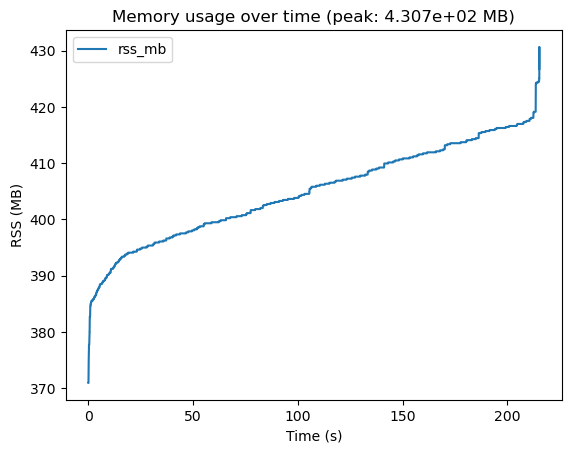

In [ ]:
print(model.memory_summary())
df_poll_2 = model.memory.poll_to_dataframe()
figure, ax = plt.subplots()
df_poll_2.plot(x="time_s", y="rss_mb", ax=ax)
ax.set_title(f"Memory usage over time (peak: {max(df_poll_2['rss_mb']):.3e} MB)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("RSS (MB)")
print(df_poll_2.head())
print(max(df_poll_2["rss_mb"]))
print(df_poll_2[df_poll_2["rss_mb"] == max(df_poll_2["rss_mb"])]["time_s"].values[0])

In [ ]:
#xpsim.export_simulation(geom, batch_stats, print_to_console=False, save_csv=True, output_dir=f'simulation_output_{geom.maj_xs_method}_{geom.maj_mat_method}_{geom.access_method}.csv')
xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= False, save_csv= True, output_dir=f'cross_batch_stats_{geom.maj_xs_method}_{geom.maj_mat_method}_{geom.access_method}.csv')